 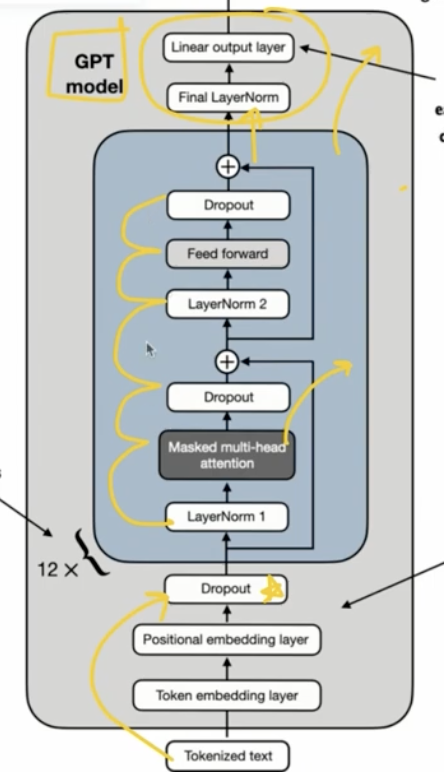

In [2]:
import torch
import torch.nn as nn 

In [3]:
from types import SimpleNamespace
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "out_dim": 768,
    "n_heads": 12, ## Number of heads in a transformer
    "n_layers": 12, ## Number of transformer layers
    "drop_rate": 0.1,
    "qkv_bias": False
}


config = SimpleNamespace(**GPT_CONFIG_124M)

In [4]:

class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True, unbiased=False)
        norm_x = (x-mean)/ torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift


class MultiHeadAttention(nn.Module):
    """
    Analyzes relationship between input elements 
    """
    def __init__(self,cfg):
        super().__init__()
        
        self.out_dim = cfg.out_dim
        self.num_heads = cfg.n_heads
        self.per_head_out_dim = self.out_dim//self.num_heads

    
        self.query_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.key_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.value_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)

        self.drop_out = nn.Dropout(cfg.drop_rate)
        self.register_buffer("mask",
            torch.triu(torch.ones(cfg.context_length,cfg.context_length),diagonal=1)
        )

        self.out_proj = nn.Linear(self.out_dim, self.out_dim)


    def forward(self,x):
        num_batches, num_input_tokens, emb_dim = x.shape
        
        ### Shape = num_batches * num_input_tokens * out_dim
        queries = self.query_matrix(x)
        keys = self.key_matrix(x)
        values = self.value_matrix(x)


        ### Attention needs to be applied head wise, so split into heads
        queries = queries.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)
        keys = keys.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)
        values = values.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)

        ### Apply transpose to push num_input_tokens , per_head_out to end
        queries = queries.transpose(1,2)
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)

        ### Compute Attention
        #1. Attention Scores
        attn_scores = queries @ keys.transpose(2,3)

        #2. Masking
        mask_bool = self.mask.bool()[:num_input_tokens,:num_input_tokens]
        attn_scores.masked_fill_(mask_bool,-torch.inf)

        #3. Attention Weights
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)

        #4. Dropout
        attn_weights=self.drop_out(attn_weights)

        #5. Context Vector
        context_vec = (attn_weights @ values).transpose(1,2)

        #6. Reshape Context Vector back
        context_vec=context_vec.contiguous().view(num_batches,num_input_tokens,self.out_dim)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec



class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (

            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0/torch.pi)) * 
                (x+0.044715 * torch.pow(x,3))
            )
        )

class FeedForwardNN(nn.Module):
    """
    Handles each token independently unlike attention
    """
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg.emb_dim, 4*cfg.emb_dim), ## Expansion
            GELU(),
            nn.Linear(4*cfg.emb_dim,cfg.emb_dim),  ## Contraction
        )
    
    def forward(self,x):
        return self.layers(x)


class Transformer(nn.Module):
    def __init__(self,cfg):
        super().__init__()

        ## Layer Normalization
        # These are called pre-LayerNorm layers as they are applied before attention and feedforward pass
        # Older version used to have pro_LayerNorm but that is found to have wrose training dynamics
        self.layer_norm1 = LayerNorm(cfg.emb_dim)
        self.layer_norm2 = LayerNorm(cfg.emb_dim)

        ## Mulit Head Attention
        self.multi_head_attention = MultiHeadAttention(cfg)

        ## FeedForward Neural Network
        self.feed_forward_nn = FeedForwardNN(cfg) 

        ## Dropout 
        self.drop_shortcut = nn.Dropout(cfg.drop_rate)
    

    def forward(self,x):

        # Shortcut connection for attention block
        shortcut = x
        x = self.layer_norm1(x)
        x = self.multi_head_attention(x) # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x= x+shortcut # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.layer_norm2(x)
        x = self.feed_forward_nn(x)
        x = self.drop_shortcut(x)
        x = x+shortcut # Add the original input back

        return x


In [5]:
class GPT2(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(
            cfg.vocab_size,cfg.emb_dim
        )

        self.pos_emb = nn.Embedding(
            cfg.context_length,cfg.emb_dim
        )

        self.drop_emb = nn.Dropout(cfg.drop_rate)

        self.trf_blocks = nn.Sequential(
            *[Transformer(cfg) for _ in range(cfg.n_layers)]
        )

        self.final_norm = LayerNorm(cfg.emb_dim)
        self.out_head = nn.Linear(
            cfg.emb_dim,cfg.vocab_size,bias = False
        )


    def forward(self,x):
        batch_size,seq_len = x.shape
        
        ### Embeddings
        embeddings = self.tok_emb(x)
        pos_embeddings = self.pos_emb(torch.arange(seq_len,device = x.device))

        final_input_embeddings = embeddings + pos_embeddings


        ### Dropout
        # - Randomly turnoff input embeddings to 0
        # prevents overfitting
        x = self.drop_emb(final_input_embeddings)


        ### Transformer
        x = self.trf_blocks(x)

        ## Layer Normalization
        x = self.final_norm(x)

        ## getting logits out of the model
        ## siz eof this is num_tokens * vocab_size
        logits = self.out_head(x)

        return logits


In [10]:
torch.manual_seed(123)

x = torch.tensor([[6109, 3626, 6100, 345],
              [6109, 1110, 6622, 257]])
        
model = GPT2(config)
output = block(x)

print("Input :", x)
print("Output :", output)

Input : tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output : tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters - {total_params}")

Total Parameters - 163009536


# But we started with 124Million GPT but now have 163Million??

<div class="alert alert-block alert-warning">
    
The reason is a concept called weight tying that is used in the original GPT-2
architecture, which means that the original GPT-2 architecture is reusing the weights from
the token embedding layer in its output layer. 

To understand what this means, let's take a
look at the shapes of the token embedding layer and linear output layer that we initialized
on the model via the GPTModel earlier:

</div>

In [13]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [14]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


<div class="alert alert-block alert-warning">
    
Weight tying reduces the overall memory footprint and computational complexity of the
model. However, in my experience, using separate token embedding and output layers
results in better training and model performance; hence, we are using separate layers in
our GPTModel implementation. The same is true for modern LLMs.

</div>

In [16]:
total_size_bytes = total_params * 4 #Assume each parametrs is a 32bit float, so its 4bytes
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB
